In [ ]:
# input
rep_info_file = "../../data/repId-numPro-numPredPro-numResi-numPredResi-numAnnoPro-isAnno.tsv"
# output
fig_file = "./fig/anno_percent_seq_cluster.pdf"

In [2]:
import pandas as pd

df_rep = pd.read_table(rep_info_file, header=None, names=["rep_id", "num_protein", "num_pred_protein", "num_residue", "num_pred_residue", "num_anno_pro", "is_anno"])

bins = []
bins.append([1,1])
for i in range(1, 10):
    bins.append([2 ** i, 2 ** (i + 1) - 1])
bins.append([2 ** 10, df_rep['num_protein'].max().item()])
def get_bin_idx(n_member):
    cur_bin_idx = None
    for idx, bin in enumerate(bins):
        lower, upper = bin
        if n_member >= lower and n_member <= upper:
            cur_bin_idx = idx
    assert cur_bin_idx != None
    return cur_bin_idx

df_rep['bin_idx'] = df_rep["num_protein"].map(lambda x: get_bin_idx(x))

In [3]:
data = []
for (idx, ), df_idx in df_rep.groupby(by=["bin_idx"]):
    data.append({
        "bin_idx": idx,
        "num_anno_cluster": len(df_idx[df_idx['num_anno_pro'] != 0]),
        "num_cluster": len(df_idx)
    })
df = pd.DataFrame(data)

df['size_ratio'] = df['num_anno_cluster'] / df['num_cluster']

df
df['num_anno_cluster'].sum() / df['num_cluster'].sum()
df['size_ratio'].sum() / 11

,bin_idx,num_anno_cluster,num_cluster,size_ratio
0,0,1999078,4191128,0.476979
1,1,1036893,1679737,0.617295
2,2,542033,776619,0.697939
3,3,283420,377757,0.750271
4,4,153803,195442,0.786950
5,5,82179,100216,0.820019
6,6,41903,50052,0.837189
7,7,21600,25296,0.853890
8,8,10631,12258,0.867270
9,9,4358,4890,0.891207


np.float64(0.5634108045029056)

np.float64(0.7751679294668702)

<Figure size 240x240 with 0 Axes>

<BarContainer object of 11 artists>

<BarContainer object of 11 artists>

Text(0, 0.5, 'Percentage')

Text(0.5, 0, 'Cluster size range length ($log_2$)')

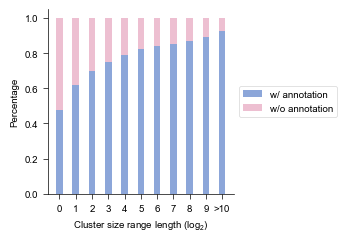

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")
plt.figure(figsize=(2.4, 2.4))

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
coor_x = np.arange(len(df))
_ = plt.xticks(coor_x, labels=[str(i)if i < 10 else f">{i}" for i in df['bin_idx']])# rotation=45, ha='right')
width = 0.4

anno_ratio = df['size_ratio']
no_anno_ratio = 1 - anno_ratio
plt.bar(coor_x, anno_ratio, width=width)
plt.bar(coor_x, no_anno_ratio, width=width, bottom=anno_ratio)

plt.ylabel("Percentage")
plt.xlabel(r"Cluster size range length ($log_2$)") # 2^i - (2^(i+1) - 1)， max 97804
plt.legend(
    labels=['w/ annotation', 'w/o annotation'],
    loc='center left',
    bbox_to_anchor=(1,0.5)
)

plt.savefig(fig_file, bbox_inches="tight", transparent=True)